<a href="https://colab.research.google.com/github/gulzhanmsc/IB9AU/blob/main/Gen_AI_Task_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Key insights:

Fine-tuning on just 60 records is a deliberate stress test, and any accuracy above random chance is genuine signal. Policy category proved more learnable than resolution, categories like billing disputes or fraud have clear keyword signals, whereas resolutions depend on context not always visible in the complaint text.
LoRA matched full fine-tuning accuracy while updating only ~1.3% of parameters, making it the practical choice for production deployment. Using DistilBERT over GPT-2 was also essential, its bidirectional encoder is purpose-built for classification, unlike generative decoders which struggle to output a single label reliably.
The key limitation is overfitting risk with so few training records. A larger dataset would substantially improve generalisation, but even at moderate accuracy, automated complaint routing and resolution prediction have clear operational value in reducing manual triage time.


In [1]:
!pip install -qU transformers datasets accelerate peft scikit-learn
print("✅ Installation complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 11.7 MB/s eta 0:00:00
✅ Installation complete.


In [2]:
# Verify GPU

import torch

if torch.cuda.is_available():
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected — training will be slow on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

✅ GPU detected: Tesla T4
   VRAM: 15.6 GB
Using device: cuda


In [4]:
# Load the Dataset
from datasets import load_dataset
import pandas as pd

ds = load_dataset("priyaannamani/credit_card_qa")
print("Dataset structure:", ds)

split_name = "train" if "train" in ds else list(ds.keys())[0]
df_full = ds[split_name].to_pandas()

print(f"\nTotal records: {len(df_full)}")
print(f"Columns: {list(df_full.columns)}")
display(df_full.head())

README.md:   0%|          | 0.00/435 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/22.8k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/80 [00:00<?, ? examples/s]

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['complaint', 'relevant_policy', 'policy_category', 'resolution', 'validity'],
        num_rows: 80
    })
})

Total records: 80
Columns: ['complaint', 'relevant_policy', 'policy_category', 'resolution', 'validity']


,complaint,relevant_policy,policy_category,resolution,validity
0,"Dana Wu, using card ending 0044, purchased $12...","You will earn 4% Cash Back on the first $25,00...",Cashback - 4%,Apply missing 4% cashback for the eligible gro...,Valid: Purchase was at an eligible merchant an...
1,Dana Wu is asking why she didn't get 4% cashba...,"You will earn 4% Cash Back on the first $25,00...",Cashback - 4%,Explain that wholesale clubs are often not cla...,Invalid: Merchant not classified as eligible g...
2,Dana Wu purchased $50 worth of electronics alo...,Some merchants may sell these products/service...,Cashback - 4%,Explain that only the grocery portion of the p...,Invalid: Non-food items purchased at a grocery...
3,Dana Wu's monthly electricity bill of $80 is a...,Recurring Bill Payments are payments made on a...,Cashback - 4%,Apply missing 4% cashback for the recurring el...,Valid: Eligible recurring utility bill payment...
4,Dana Wu's $300 car loan payment is automatical...,Recurring Bill Payments are payments made on a...,Cashback - 4%,Explain that loan payments are not typically c...,Invalid: Loan payments are not eligible recurr...


POLICY CATEGORY distribution:
policy_category
Cashback - 4%                                20
Purchase Security                            20
Cashback - Exclusions                         7
Contact Information - Insurance               5
Cashback - 2%                                 3
Contact Information - Protection Services     3
Contact Information - Banking                 2
Cashback - 2% Gas                             2
Contact Information - Emergency Services      2
Contact Information                           2
Cashback - Redemption                         2
Cashback - Eligible Categories                2
Contact Information - Concierge               2
Cashback - Foreign Transactions               1
Cashback - 1% Groceries                       1
Cashback - Calculation                        1
Cashback - Expiration                         1
Miscellaneous - Program Termination           1
Cashback - Posting Timeline                   1
Miscellaneous - Program Changes           

/tmp/ipykernel_9972/1012813103.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


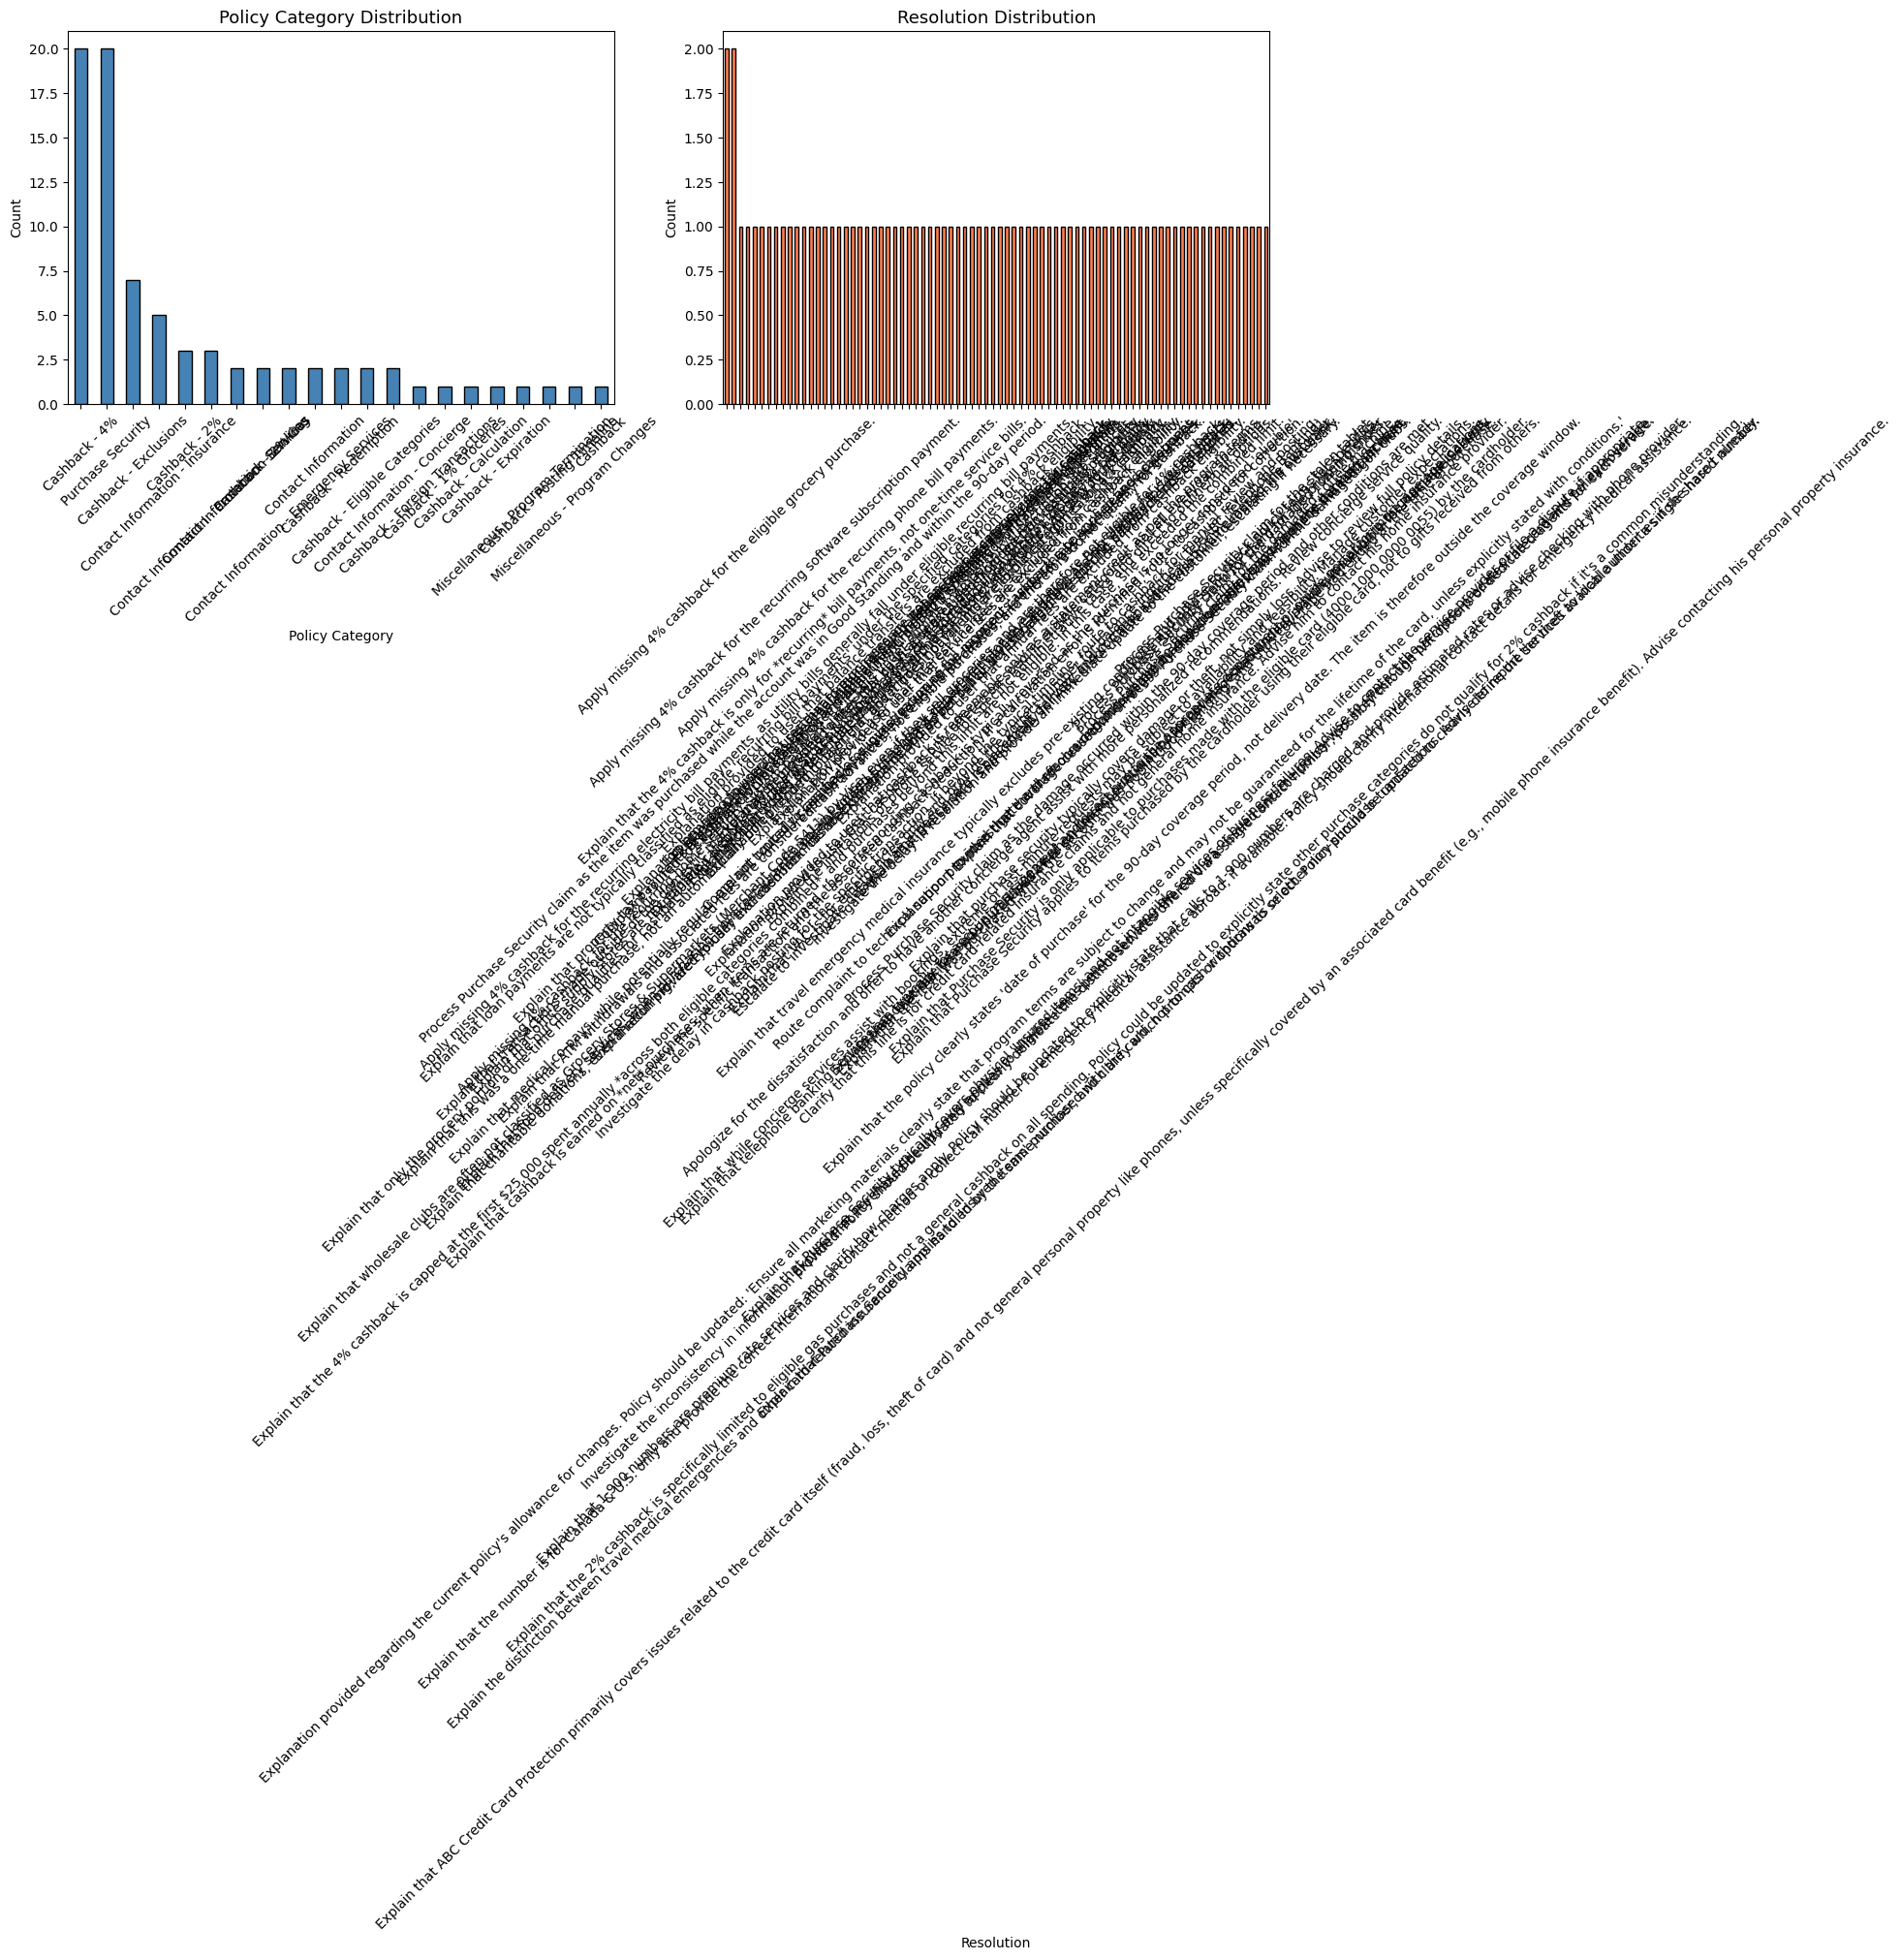

In [5]:
# Explore the Data
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("POLICY CATEGORY distribution:")
print(df_full['policy_category'].value_counts())
print(f"\nUnique policy categories: {df_full['policy_category'].nunique()}")

print("\n" + "=" * 60)
print("RESOLUTION distribution:")
print(df_full['resolution'].value_counts())
print(f"\nUnique resolutions: {df_full['resolution'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_full['policy_category'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Policy Category Distribution', fontsize=13)
axes[0].set_xlabel('Policy Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df_full['resolution'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Resolution Distribution', fontsize=13)
axes[1].set_xlabel('Resolution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# Encode Labels
# Policy Category encoding
policy_categories = sorted(df_full['policy_category'].dropna().unique().tolist())
policy_label2id   = {label: idx for idx, label in enumerate(policy_categories)}
policy_id2label   = {idx: label for label, idx in policy_label2id.items()}
num_policy_labels = len(policy_categories)

print(f"Policy categories ({num_policy_labels}):")
for k, v in policy_label2id.items():
    print(f"  {v}: {k}")

# Resolution encoding
resolutions    = sorted(df_full['resolution'].dropna().unique().tolist())
res_label2id   = {label: idx for idx, label in enumerate(resolutions)}
res_id2label   = {idx: label for label, idx in res_label2id.items()}
num_res_labels = len(resolutions)

print(f"\nResolutions ({num_res_labels}):")
for k, v in res_label2id.items():
    print(f"  {v}: {k}")

# Add integer label columns
df_full['policy_label'] = df_full['policy_category'].map(policy_label2id)
df_full['res_label']    = df_full['resolution'].map(res_label2id)

# Drop rows with NaN labels
df_full = df_full.dropna(subset=['policy_label', 'res_label', 'complaint']).reset_index(drop=True)
df_full['policy_label'] = df_full['policy_label'].astype(int)
df_full['res_label']    = df_full['res_label'].astype(int)

print(f"\nClean dataset size: {len(df_full)} records")

Policy categories (21):
  0: Cashback
  1: Cashback - 1% Groceries
  2: Cashback - 2%
  3: Cashback - 2% Gas
  4: Cashback - 4%
  5: Cashback - Calculation
  6: Cashback - Eligible Categories
  7: Cashback - Exclusions
  8: Cashback - Expiration
  9: Cashback - Foreign Transactions
  10: Cashback - Posting Timeline
  11: Cashback - Redemption
  12: Contact Information
  13: Contact Information - Banking
  14: Contact Information - Concierge
  15: Contact Information - Emergency Services
  16: Contact Information - Insurance
  17: Contact Information - Protection Services
  18: Miscellaneous - Program Changes
  19: Miscellaneous - Program Termination
  20: Purchase Security

Resolutions (78):
  0: Apologize for the dissatisfaction and offer to have another concierge agent assist with more personalized recommendations. Review concierge service quality.
  1: Apply missing 4% cashback for the eligible grocery purchase.
  2: Apply missing 4% cashback for the recurring electricity bill payme

In [7]:
# Sample 60 Records for Fine-Tuning
from datasets import Dataset

SAMPLE_SIZE = 60
df_train = df_full.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
df_eval  = df_full.copy()  # Evaluate on ALL records

print(f"Training sample:    {len(df_train)} records")
print(f"Evaluation dataset: {len(df_eval)} records (full dataset)")

# Convert to HuggingFace Dataset objects
train_ds_policy = Dataset.from_pandas(df_train[['complaint', 'policy_label']].rename(columns={'policy_label': 'label'}))
train_ds_res    = Dataset.from_pandas(df_train[['complaint', 'res_label']].rename(columns={'res_label': 'label'}))

eval_ds_policy  = Dataset.from_pandas(df_eval[['complaint', 'policy_label']].rename(columns={'policy_label': 'label'}))
eval_ds_res     = Dataset.from_pandas(df_eval[['complaint', 'res_label']].rename(columns={'res_label': 'label'}))

print("Datasets prepared ✅")

Training sample:    60 records
Evaluation dataset: 80 records (full dataset)
Datasets prepared ✅


In [8]:
# Load Tokeniser
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(
        examples['complaint'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

tok_train_policy = train_ds_policy.map(tokenize_fn, batched=True).remove_columns(['complaint'])
tok_train_res    = train_ds_res.map(tokenize_fn, batched=True).remove_columns(['complaint'])

tok_eval_policy  = eval_ds_policy.map(tokenize_fn, batched=True).remove_columns(['complaint'])
tok_eval_res     = eval_ds_res.map(tokenize_fn, batched=True).remove_columns(['complaint'])

print("✅ Tokenisation complete.")
print(f"Training columns: {tok_train_policy.column_names}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

✅ Tokenisation complete.
Training columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [10]:
# Model A: Full Fine-Tuning (policy_category)
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, classification_report

model_a_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_policy_labels,
    id2label=policy_id2label,
    label2id=policy_label2id
)

total_params_a = sum(p.numel() for p in model_a_full.parameters())
print(f"Total parameters (Model A Full): {total_params_a:,}")

args_a_full = TrainingArguments(
    output_dir="./model_a_full_ft",
    per_device_train_batch_size=4,
    num_train_epochs=15,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    logging_dir="./logs",
    report_to="none",
    save_strategy="no"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_a_full = Trainer(
    model=model_a_full,
    args=args_a_full,
    train_dataset=tok_train_policy,
    data_collator=data_collator,
    processing_class=tokenizer
)

print("\nTraining Model A (Full Fine-Tuning — policy_category)...")
trainer_a_full.train()
print("✅ Model A Full Fine-Tuning complete.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Total parameters (Model A Full): 66,969,621

Training Model A (Full Fine-Tuning — policy_category)...


Step,Training Loss


✅ Model A Full Fine-Tuning complete.


In [11]:
# Evaluate Model A Full

model_a_full.eval()
model_a_full.to(device)

preds_a_full = []
true_a       = []

for i in range(len(tok_eval_policy)):
    example        = tok_eval_policy[i]
    input_ids      = torch.tensor([example['input_ids']]).to(device)
    attention_mask = torch.tensor([example['attention_mask']]).to(device)
    true_a.append(example['label'])

    with torch.no_grad():
        logits = model_a_full(input_ids=input_ids, attention_mask=attention_mask).logits
        preds_a_full.append(torch.argmax(logits, dim=-1).item())

acc_a_full = accuracy_score(true_a, preds_a_full)
print(f"Model A Full FT Accuracy (on all {len(df_full)} records): {acc_a_full:.4f}")
print("\nClassification Report:")
print(classification_report(true_a, preds_a_full, target_names=policy_categories, zero_division=0))

Model A Full FT Accuracy (on all 80 records): 0.7875

Classification Report:
                                           precision    recall  f1-score   support

                                 Cashback       1.00      1.00      1.00         1
                  Cashback - 1% Groceries       0.00      0.00      0.00         1
                            Cashback - 2%       1.00      1.00      1.00         3
                        Cashback - 2% Gas       0.00      0.00      0.00         2
                            Cashback - 4%       1.00      1.00      1.00        20
                   Cashback - Calculation       0.00      0.00      0.00         1
           Cashback - Eligible Categories       0.00      0.00      0.00         2
                    Cashback - Exclusions       0.35      1.00      0.52         7
                    Cashback - Expiration       0.00      0.00      0.00         1
          Cashback - Foreign Transactions       0.00      0.00      0.00         1
         

In [13]:
# Model A: LoRA Fine-Tuning (policy_category)

from peft import LoraConfig, get_peft_model, TaskType

model_a_lora_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_policy_labels,
    id2label=policy_id2label,
    label2id=policy_label2id
)

lora_config_a = LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS,
    target_modules=["q_lin", "k_lin", "v_lin", "out_lin"]
)

model_a_lora = get_peft_model(model_a_lora_base, lora_config_a)
model_a_lora.print_trainable_parameters()

args_a_lora = TrainingArguments(
    output_dir="./model_a_lora",
    per_device_train_batch_size=4,
    num_train_epochs=40,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=50,
    logging_dir="./logs",
    report_to="none",
    save_strategy="no"
)

trainer_a_lora = Trainer(
    model=model_a_lora,
    args=args_a_lora,
    train_dataset=tok_train_policy,
    data_collator=data_collator,
)

print("\nTraining Model A (LoRA — policy_category)...")
trainer_a_lora.train()
print("✅ Model A LoRA training complete.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 901,653 || all params: 67,871,274 || trainable%: 1.3285

Training Model A (LoRA — policy_category)...


Step,Training Loss
500,0.573316


✅ Model A LoRA training complete.


In [14]:
# Evaluate Model A LoRA

model_a_lora.eval()
model_a_lora.to(device)

preds_a_lora = []

for i in range(len(tok_eval_policy)):
    example        = tok_eval_policy[i]
    input_ids      = torch.tensor([example['input_ids']]).to(device)
    attention_mask = torch.tensor([example['attention_mask']]).to(device)

    with torch.no_grad():
        logits = model_a_lora(input_ids=input_ids, attention_mask=attention_mask).logits
        preds_a_lora.append(torch.argmax(logits, dim=-1).item())

acc_a_lora = accuracy_score(true_a, preds_a_lora)
print(f"Model A LoRA Accuracy (on all {len(df_full)} records): {acc_a_lora:.4f}")
print("\nClassification Report:")
print(classification_report(true_a, preds_a_lora, target_names=policy_categories, zero_division=0))

Model A LoRA Accuracy (on all 80 records): 0.9250

Classification Report:
                                           precision    recall  f1-score   support

                                 Cashback       1.00      1.00      1.00         1
                  Cashback - 1% Groceries       0.00      0.00      0.00         1
                            Cashback - 2%       0.75      1.00      0.86         3
                        Cashback - 2% Gas       1.00      0.50      0.67         2
                            Cashback - 4%       1.00      1.00      1.00        20
                   Cashback - Calculation       1.00      1.00      1.00         1
           Cashback - Eligible Categories       1.00      0.50      0.67         2
                    Cashback - Exclusions       0.70      1.00      0.82         7
                    Cashback - Expiration       1.00      1.00      1.00         1
          Cashback - Foreign Transactions       1.00      1.00      1.00         1
            

In [16]:
# Model B: Full Fine-Tuning (resolution)

model_b_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_res_labels,
    id2label=res_id2label,
    label2id=res_label2id
)

total_params_b = sum(p.numel() for p in model_b_full.parameters())
print(f"Total parameters (Model B Full): {total_params_b:,}")

args_b_full = TrainingArguments(
    output_dir="./model_b_full_ft",
    per_device_train_batch_size=4,
    num_train_epochs=15,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    logging_dir="./logs",
    report_to="none",
    save_strategy="no"
)

trainer_b_full = Trainer(
    model=model_b_full,
    args=args_b_full,
    train_dataset=tok_train_res,
    data_collator=data_collator,
    processing_class=tokenizer
)

print("\nTraining Model B (Full Fine-Tuning — resolution)...")
trainer_b_full.train()
print("✅ Model B Full Fine-Tuning complete.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Total parameters (Model B Full): 67,013,454

Training Model B (Full Fine-Tuning — resolution)...


Step,Training Loss


✅ Model B Full Fine-Tuning complete.


In [17]:
# Evaluate Model B Full

model_b_full.eval()
model_b_full.to(device)

preds_b_full = []
true_b       = []

for i in range(len(tok_eval_res)):
    example        = tok_eval_res[i]
    input_ids      = torch.tensor([example['input_ids']]).to(device)
    attention_mask = torch.tensor([example['attention_mask']]).to(device)
    true_b.append(example['label'])

    with torch.no_grad():
        logits = model_b_full(input_ids=input_ids, attention_mask=attention_mask).logits
        preds_b_full.append(torch.argmax(logits, dim=-1).item())

acc_b_full = accuracy_score(true_b, preds_b_full)
print(f"Model B Full FT Accuracy (on all {len(df_full)} records): {acc_b_full:.4f}")
print("\nClassification Report:")
print(classification_report(true_b, preds_b_full, target_names=resolutions, zero_division=0))

Model B Full FT Accuracy (on all 80 records): 0.6625

Classification Report:
                                                                                                                                                                                                                                                                                                                                    precision    recall  f1-score   support

                                                                                                                                                                      Apologize for the dissatisfaction and offer to have another concierge agent assist with more personalized recommendations. Review concierge service quality.       1.00      1.00      1.00         1
                                                                                                                                                                                                  

In [19]:
# Model B: LoRA Fine-Tuning (resolution)

model_b_lora_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_res_labels,
    id2label=res_id2label,
    label2id=res_label2id
)

lora_config_b = LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS,
    target_modules=["q_lin", "k_lin", "v_lin", "out_lin"]
)

model_b_lora = get_peft_model(model_b_lora_base, lora_config_b)
model_b_lora.print_trainable_parameters()

args_b_lora = TrainingArguments(
    output_dir="./model_b_lora",
    per_device_train_batch_size=4,
    num_train_epochs=40,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=50,
    logging_dir="./logs",
    report_to="none",
    save_strategy="no"
)

trainer_b_lora = Trainer(
    model=model_b_lora,
    args=args_b_lora,
    train_dataset=tok_train_res,
    data_collator=data_collator,
)

print("\nTraining Model B (LoRA — resolution)...")
trainer_b_lora.train()
print("✅ Model B LoRA training complete.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 945,486 || all params: 67,958,940 || trainable%: 1.3913

Training Model B (LoRA — resolution)...


Step,Training Loss
500,1.468286


✅ Model B LoRA training complete.


In [20]:
# Evaluate Model B LoRA

model_b_lora.eval()
model_b_lora.to(device)

preds_b_lora = []

for i in range(len(tok_eval_res)):
    example        = tok_eval_res[i]
    input_ids      = torch.tensor([example['input_ids']]).to(device)
    attention_mask = torch.tensor([example['attention_mask']]).to(device)

    with torch.no_grad():
        logits = model_b_lora(input_ids=input_ids, attention_mask=attention_mask).logits
        preds_b_lora.append(torch.argmax(logits, dim=-1).item())

acc_b_lora = accuracy_score(true_b, preds_b_lora)
print(f"Model B LoRA Accuracy (on all {len(df_full)} records): {acc_b_lora:.4f}")
print("\nClassification Report:")
print(classification_report(true_b, preds_b_lora, target_names=resolutions, zero_division=0))

Model B LoRA Accuracy (on all 80 records): 0.7500

Classification Report:
                                                                                                                                                                                                                                                                                                                                    precision    recall  f1-score   support

                                                                                                                                                                      Apologize for the dissatisfaction and offer to have another concierge agent assist with more personalized recommendations. Review concierge service quality.       1.00      1.00      1.00         1
                                                                                                                                                                                                     

,Task,Approach,Total Parameters,Trainable Parameters,Trainable %,Accuracy (all records)
0,Policy Category,Full Fine-Tuning,66969621,66969621,100.00,0.7875
1,Policy Category,LoRA (PEFT),66969621,901653,1.35,0.9250
2,Resolution,Full Fine-Tuning,67013454,67013454,100.00,0.6625
3,Resolution,LoRA (PEFT),67013454,945486,1.41,0.7500


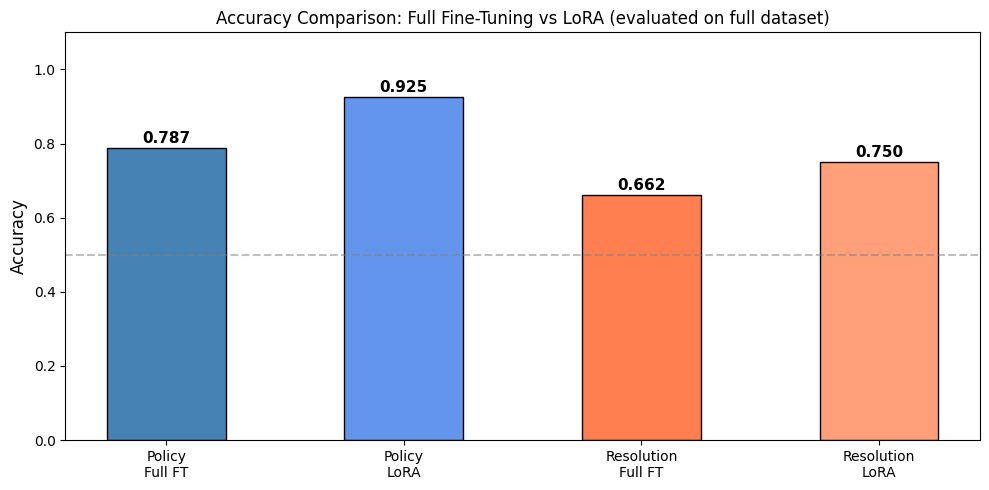

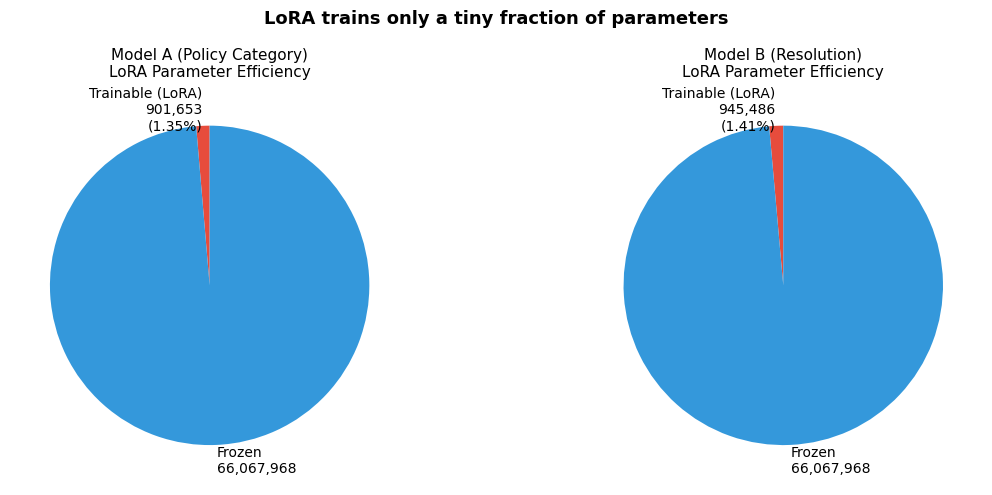

In [21]:
# Comparative Summary & Charts

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

trainable_lora_a = sum(p.numel() for p in model_a_lora.parameters() if p.requires_grad)
trainable_lora_b = sum(p.numel() for p in model_b_lora.parameters() if p.requires_grad)

summary = pd.DataFrame({
    'Task':                   ['Policy Category', 'Policy Category', 'Resolution', 'Resolution'],
    'Approach':               ['Full Fine-Tuning', 'LoRA (PEFT)', 'Full Fine-Tuning', 'LoRA (PEFT)'],
    'Total Parameters':       [total_params_a, total_params_a, total_params_b, total_params_b],
    'Trainable Parameters':   [total_params_a, trainable_lora_a, total_params_b, trainable_lora_b],
    'Trainable %':            [
        100.0,
        round(100 * trainable_lora_a / total_params_a, 2),
        100.0,
        round(100 * trainable_lora_b / total_params_b, 2)
    ],
    'Accuracy (all records)': [acc_a_full, acc_a_lora, acc_b_full, acc_b_lora]
})

display(summary)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
labels   = ['Policy\nFull FT', 'Policy\nLoRA', 'Resolution\nFull FT', 'Resolution\nLoRA']
acc_vals = [acc_a_full, acc_a_lora, acc_b_full, acc_b_lora]
colours  = ['steelblue', 'cornflowerblue', 'coral', 'lightsalmon']
bars = ax.bar(labels, acc_vals, color=colours, edgecolor='black', width=0.5)

for bar, val in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy Comparison: Full Fine-Tuning vs LoRA (evaluated on full dataset)', fontsize=12)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
plt.tight_layout()
plt.show()

# Parameter efficiency pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, title, total, trainable_lora in zip(
    axes,
    ['Model A (Policy Category)', 'Model B (Resolution)'],
    [total_params_a, total_params_b],
    [trainable_lora_a, trainable_lora_b]
):
    frozen = total - trainable_lora
    sizes  = [trainable_lora, frozen]
    labels_pie = [
        f'Trainable (LoRA)\n{trainable_lora:,}\n({100*trainable_lora/total:.2f}%)',
        f'Frozen\n{frozen:,}'
    ]
    ax.pie(sizes, labels=labels_pie, colors=['#e74c3c', '#3498db'], startangle=90)
    ax.set_title(f'{title}\nLoRA Parameter Efficiency', fontsize=11)

plt.suptitle('LoRA trains only a tiny fraction of parameters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()